# Decision Tree Classifier

In [26]:
#import libraries

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

#
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score

In [4]:
#load the dataset for multiclass classification
data = sns.load_dataset("iris")
data[:5]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
#shape
data.shape

(150, 5)

In [6]:
#data type
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
#check null values
data.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [8]:
#check duplicates

data.duplicated().sum()

#drop
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [9]:
#convert label to numeric

data["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [10]:
#convert label to numeric
data["species"] = data["species"].map({'setosa':0, 'versicolor':1, 'virginica':2})

data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [11]:
data["species"].value_counts()

species
0    50
1    50
2    49
Name: count, dtype: int64

In [12]:
#seperate data into label and features set

X = data.drop("species", axis=1)
y = data['species']

In [13]:
#seperate train and test set

x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=.2, random_state=42, stratify=y)

In [14]:
#train the model

model  =DecisionTreeClassifier()

model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
#check score on training set
model.score(x_train, y_train)

1.0

In [16]:
#predict
y_pred = model.predict(x_test)

pd.DataFrame({"actual": y_test, "Predicted": y_pred})[:5]

,actual,Predicted
69,1,1
66,1,1
141,2,2
7,0,0
147,2,2


In [17]:
#accuracy
accuracy_score(y_test, y_pred)

0.9333333333333333

In [18]:
#confusion matrix

conm = confusion_matrix(y_test, y_pred)
conm

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  1,  9]])

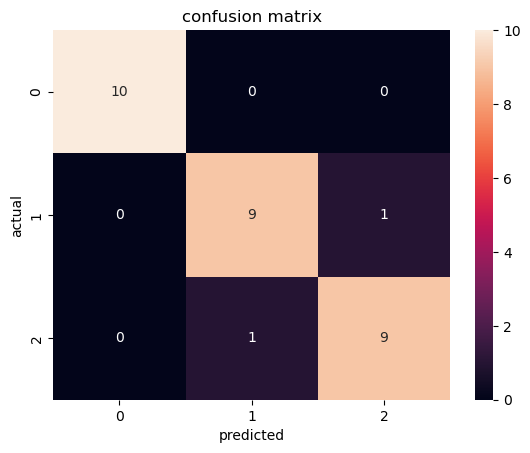

In [19]:
sns.heatmap(conm, annot=True)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix");

In [20]:
#get claiification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



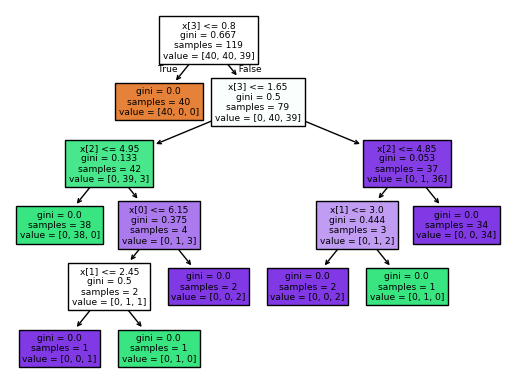

In [21]:
#plot the model
tree.plot_tree(model, filled=True);

## Feature importance  

This is done after model

In [22]:
#check feature importance

feature = model.feature_importances_
feature

array([0.00630297, 0.02941384, 0.05904671, 0.90523649])

In [23]:
names = model.feature_names_in_
names

array(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
      dtype=object)

In [24]:
feature_df = pd.DataFrame({"feature_name": names, "feature_val": feature})
feature_df.sort_values(by="feature_val", ascending=False)

,feature_name,feature_val
3,petal_width,0.905236
2,petal_length,0.059047
1,sepal_width,0.029414
0,sepal_length,0.006303


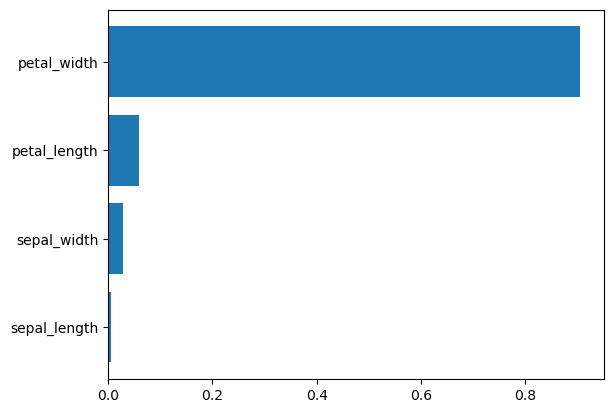

In [25]:
#visualize this barchart

plt.barh(feature_df["feature_name"], feature_df["feature_val"]);

## Hyperparameter Tuning

In [27]:
#import hyperemeter package
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [33]:
#Get the params

param_g = {"criterion": ["gini", "entropy"],
              "max_depth" : [3, 5, 7, 8, None],
              "min_samples_split": [2, 5, 8, 10]
             }

In [34]:
grid_search = GridSearchCV(estimator=model, param_grid=param_g, cv=5, scoring='accuracy')

grid_search.fit(x_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [36]:
grid_search.best_params_

{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}

In [37]:
#check training score
grid_search.score(x_train, y_train)

0.9831932773109243

In [39]:
#predict grid
y_pred2 = grid_search.predict(x_test)


#get accuracy
accuracy_score(y_test, y_pred2)

0.9666666666666667

### Always rectreate the model with the optimal parameters



In [41]:
#Rectreating the model with the optimal featutes

model2 = DecisionTreeClassifier(criterion = 'gini', max_depth= 5, min_samples_split= 5)
model2.fit(x_train, y_train)


#get the score
model2.score(x_train, y_train)

0.9831932773109243

In [43]:
#check predict

y_pred3 = model2.predict(x_test)

#
pd.DataFrame({"actual": y_test, "Predicted": y_pred3})[:6]

,actual,Predicted
69,1,1
66,1,1
141,2,2
7,0,0
147,2,2
57,1,1


In [44]:
#check accuracy

accuracy_score(y_test, y_pred3)

0.9666666666666667

In [45]:
#check confusion matrix

cm1 =confusion_matrix(y_test, y_pred3)
cm1

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  0, 10]])

### RandomSearchCV

In [46]:
#import the librararies
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [48]:
# creat parameter distribution
param_dist = {"criterion": ["gini", "entropy"],
              "max_depth" : randint(2, 10),
              "min_samples_split":randint(2,10)
             }

In [50]:
#instantiate randomsearch

random_search = RandomizedSearchCV(estimator= model, param_distributions=param_dist,\
                                   cv=5, scoring="accuracy", random_state=42)

In [51]:
#fit and get best params
random_search.fit(x_train, y_train)

,estimator,DecisionTreeClassifier()
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': <scipy.stats....001323423C830>, 'min_samples_split': <scipy.stats....00132409B6990>}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [52]:
#Get best params

random_search.best_params_

{'criterion': 'entropy', 'max_depth': 4, 'min_samples_split': 7}

In [54]:
#rectreate the model
model4 = DecisionTreeClassifier(criterion = 'entropy', max_depth = 4, min_samples_split =7)

#train themodel

model4.fit(x_train, y_train)

#check model score
model4.score(x_train, y_train)

0.9831932773109243

In [55]:
#predict
y_pred4 = model4.predict(x_test)

In [56]:
#check model accuracy on test set
accuracy_score(y_test, y_pred4)

0.9666666666666667

In [58]:
#confusion matrix

confusion_matrix(y_test, y_pred4)

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  0, 10]])

In [60]:
#classification report

print(classification_report(y_test, y_pred4))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [61]:
#check feature importance values
model4.feature_importances_

array([0.        , 0.        , 0.68911752, 0.31088248])

In [62]:
#feature importance name
model4.feature_names_in_

array(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
      dtype=object)